# **Graph Neural Networks: clasificación de nodos con Cora**

## **1. Objetivo del notebook**

Este notebook muestra de forma visual y reproducible cómo funciona una Graph Neural Network.

La idea principal es comparar:

- **MLP:** usa solo atributos de los nodos.
- **GCN:** usa atributos de los nodos y relaciones del grafo.

El ejemplo final usa el dataset **Cora**, una red de citaciones científicas.

## **2. Instalación de librerías**

In [1]:
# Instala PyTorch Geometric y NetWorkx
%pip install torch-geometric -q
%pip install networkx -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.8 MB/s eta 0:00:00


## **3. Importación de librerías**

In [2]:
# Importamos PyTorch, que será la base para construir y entrenar redes neuronales,
# módulos de redes neuronales de PyTorch, funciones como ReLU, dropout y cross entropy.
import torch
import torch.nn as nn
import torch.nn.functional as F

# Importamos PyTorch Geometric para trabajar con grafos, transformaciones de PyTorch Geometric.
# la capa GCNConv para construir la Graph Convolutional Network.
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv

# Importa NetworkX para construir y visualizar grafos.
import networkx as nx

# Importamos librerías adicionales.
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np

## **4. Mini-ejemplos de grafos**

En esta sección se construyen diferentes tipos de grafos usando `NetworkX`:

1. Grafo no dirigido  
2. Grafo dirigido  
3. Grafo ponderado  
4. Grafo dirigido y ponderado  
5. Grafo bipartito  

La idea es visualizar cada grafo y su representación matricial.

In [3]:
def dibujar_grafo(G, titulo, pos=None, pesos=False, node_color="#1f77b4"):
    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(7, 4))

    widths = 1.5
    if pesos:
        widths = [G[u][v]["weight"] * 1.3 for u, v in G.edges()]

    draw_kwargs = {
        "G": G,
        "pos": pos,
        "with_labels": True,
        "node_size": 1200,
        "node_color": node_color,
        "font_size": 12,
        "width": widths
    }

    if G.is_directed():
        draw_kwargs["arrows"] = True
        draw_kwargs["arrowsize"] = 22
        draw_kwargs["arrowstyle"] = "-|>"
        draw_kwargs["connectionstyle"] = "arc3,rad=0.05"

    nx.draw_networkx(**draw_kwargs)

    if pesos:
        edge_labels = nx.get_edge_attributes(G, "weight")
        nx.draw_networkx_edge_labels(
            G,
            pos=pos,
            edge_labels=edge_labels,
            font_size=10
        )

    plt.title(titulo)
    plt.axis("off")
    plt.show()

    return pos

In [4]:
def mostrar_matriz_adyacencia(G, titulo, weight=None, width=600, height=500):
    nodos = list(G.nodes())
    dtype = float if weight else int

    A = nx.to_numpy_array(G, nodelist=nodos, weight=weight, dtype=dtype)

    A_df = pd.DataFrame(
        A,
        index=[f"Nodo {i}" for i in nodos],
        columns=[f"Nodo {i}" for i in nodos]
    )

    display(A_df)

    fig = px.imshow(
        A_df,
        text_auto=".1f" if weight else True,
        title=titulo,
        color_continuous_scale="Tealgrn",
        labels=dict(
            x="Nodo destino",
            y="Nodo origen",
            color="Peso" if weight else "Conexión"
        )
    )

    fig.update_layout(
        width=width,
        height=height,
        margin=dict(l=40, r=40, t=70, b=40),
        title=dict(x=0.5),
    )

    fig.update_coloraxes(
        colorbar=dict(
            thickness=14,
            len=0.75
        )
    )

    fig.show(config={"displayModeBar": False})

    return A, A_df

### **4.1. Grafo no dirigido**


Un grafo no dirigido representa relaciones sin orientación.

Si existe una conexión entre el nodo 0 y el nodo 1, entonces la relación se interpreta en ambos sentidos:

$$
0 \leftrightarrow 1
$$

En este tipo de grafo, la matriz de adyacencia suele ser simétrica.

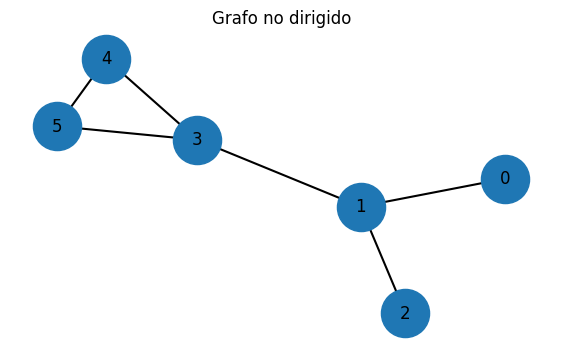

In [5]:
G = nx.Graph()

G.add_nodes_from([0, 1, 2, 3, 4, 5])

G.add_edges_from([
    (0, 1),
    (1, 2),
    (1, 3),
    (3, 4),
    (3, 5),
    (4, 5)
])

pos = dibujar_grafo(G, "Grafo no dirigido")

#### **Matriz de adyacencia del grafo no dirigido**

La matriz de adyacencia indica qué nodos están conectados.

- $A[i,j] = 1$ si existe conexión entre el nodo $i$ y el nodo $j$.
- $A[i,j] = 0$ si no existe conexión.

In [6]:
A, A_df = mostrar_matriz_adyacencia(
    G,
    "Matriz de adyacencia - Grafo no dirigido"
)

print("¿La matriz es simétrica?", np.array_equal(A, A.T))

,Nodo 0,Nodo 1,Nodo 2,Nodo 3,Nodo 4,Nodo 5
Nodo 0,0,1,0,0,0,0
Nodo 1,1,0,1,1,0,0
Nodo 2,0,1,0,0,0,0
Nodo 3,0,1,0,0,1,1
Nodo 4,0,0,0,1,0,1
Nodo 5,0,0,0,1,1,0


¿La matriz es simétrica? True


### **4.2. Grafo dirigido**



Un grafo dirigido representa relaciones con orientación.

Una arista:

$$
0 \rightarrow 1
$$

significa que existe una conexión desde el nodo 0 hacia el nodo 1, pero no necesariamente desde el nodo 1 hacia el nodo 0.

En este caso, la matriz de adyacencia no necesariamente es simétrica.

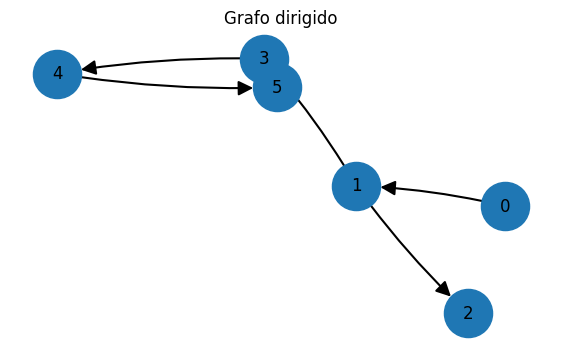

In [7]:
G_dir = nx.DiGraph()

G_dir.add_nodes_from([0, 1, 2, 3, 4, 5])

G_dir.add_edges_from([
    (0, 1),
    (1, 2),
    (1, 3),
    (3, 4),
    (5, 3),
    (4, 5)
])

pos_dir = dibujar_grafo(G_dir, "Grafo dirigido")

#### **Matriz de adyacencia del grafo dirigido**

En un grafo dirigido:

$$
A[i,j] = 1
$$

significa que existe una arista desde el nodo $i$ hacia el nodo $j$.

In [8]:
A_dir, A_dir_df = mostrar_matriz_adyacencia(
    G_dir,
    "Matriz de adyacencia - Grafo dirigido"
)

print("\n¿La matriz es simétrica?", np.array_equal(A_dir, A_dir.T))

,Nodo 0,Nodo 1,Nodo 2,Nodo 3,Nodo 4,Nodo 5
Nodo 0,0,1,0,0,0,0
Nodo 1,0,0,1,1,0,0
Nodo 2,0,0,0,0,0,0
Nodo 3,0,0,0,0,1,0
Nodo 4,0,0,0,0,0,1
Nodo 5,0,0,0,1,0,0



¿La matriz es simétrica? False


### **4.3. Grafo ponderado**



Un grafo ponderado tiene pesos en sus aristas.

El peso puede representar:

- distancia;
- costo;
- intensidad;
- frecuencia;
- similitud.

En este caso, la matriz de adyacencia no contiene solo 0 y 1, sino los pesos de las conexiones.

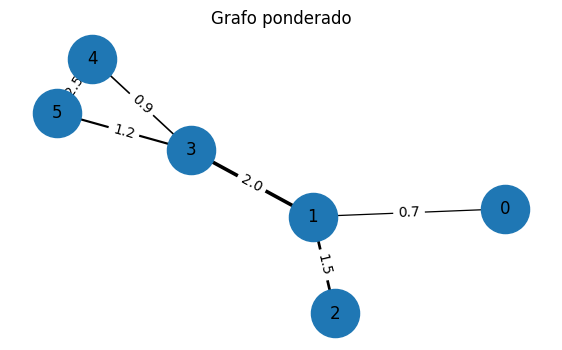

In [9]:
G_weighted = nx.Graph()

G_weighted.add_weighted_edges_from([
    (0, 1, 0.7),
    (1, 2, 1.5),
    (1, 3, 2.0),
    (3, 4, 0.9),
    (3, 5, 1.2),
    (4, 5, 2.5)
])

pos_weighted = dibujar_grafo(
    G_weighted,
    "Grafo ponderado",
    pesos=True
)

#### **Matriz de adyacencia del grafo ponderado**

En un grafo ponderado:

$$
A[i,j] = w
$$

donde $w$ representa el peso de la conexión entre los nodos $i$ y $j$.

In [10]:
A_weighted, A_weighted_df = mostrar_matriz_adyacencia(
    G_weighted,
    "Matriz de adyacencia - Grafo ponderado",
    weight="weight"
)

print("\n¿La matriz es simétrica?", np.array_equal(A_weighted, A_weighted.T))

,Nodo 0,Nodo 1,Nodo 2,Nodo 3,Nodo 4,Nodo 5
Nodo 0,0.0,0.7,0.0,0.0,0.0,0.0
Nodo 1,0.7,0.0,1.5,2.0,0.0,0.0
Nodo 2,0.0,1.5,0.0,0.0,0.0,0.0
Nodo 3,0.0,2.0,0.0,0.0,0.9,1.2
Nodo 4,0.0,0.0,0.0,0.9,0.0,2.5
Nodo 5,0.0,0.0,0.0,1.2,2.5,0.0



¿La matriz es simétrica? True


### **4.4. Grafo dirigido y ponderado**



Un grafo dirigido y ponderado combina dos ideas:

1. Las aristas tienen dirección.
2. Las aristas tienen peso.

Este tipo de grafo puede representar rutas, transferencias, flujos o relaciones con intensidad.

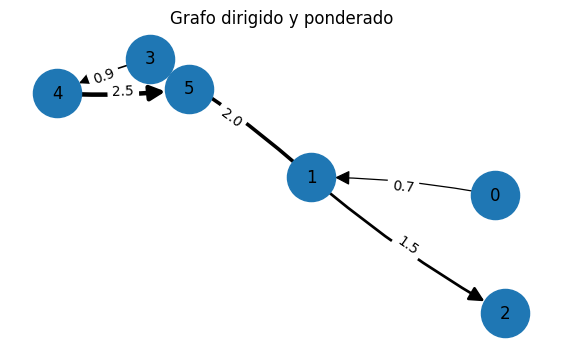

In [11]:
G_dir_weighted = nx.DiGraph()

G_dir_weighted.add_weighted_edges_from([
    (0, 1, 0.7),
    (1, 2, 1.5),
    (1, 3, 2.0),
    (3, 4, 0.9),
    (5, 3, 1.2),
    (4, 5, 2.5)
])

pos_dir_weighted = dibujar_grafo(
    G_dir_weighted,
    "Grafo dirigido y ponderado",
    pesos=True
)

#### **Matriz de adyacencia del grafo dirigido y ponderado**

En este caso:

$$
A[i,j] = w
$$

significa que existe una arista desde el nodo $i$ hacia el nodo $j$ con peso $w$.

In [12]:
A_dir_weighted, A_dir_weighted_df = mostrar_matriz_adyacencia(
    G_dir_weighted,
    "Matriz de adyacencia - Grafo dirigido y ponderado",
    weight="weight"
)

print("\n¿La matriz es simétrica?", np.array_equal(A_dir_weighted, A_dir_weighted.T))

,Nodo 0,Nodo 1,Nodo 2,Nodo 3,Nodo 4,Nodo 5
Nodo 0,0.0,0.7,0.0,0.0,0.0,0.0
Nodo 1,0.0,0.0,1.5,2.0,0.0,0.0
Nodo 2,0.0,0.0,0.0,0.0,0.0,0.0
Nodo 3,0.0,0.0,0.0,0.0,0.9,0.0
Nodo 4,0.0,0.0,0.0,0.0,0.0,2.5
Nodo 5,0.0,0.0,0.0,1.2,0.0,0.0



¿La matriz es simétrica? False


### **4.5. Grafo bipartito**



Un grafo bipartito tiene dos grupos de nodos.

Las conexiones ocurren entre nodos de grupos diferentes, no dentro del mismo grupo.

Ejemplo:

- Grupo 1: usuarios.
- Grupo 2: productos.

Este tipo de grafo es común en sistemas de recomendación.

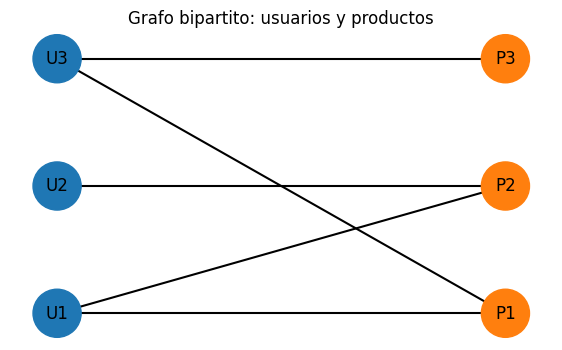

{'U1': (0, 0),
 'U2': (0, 1),
 'U3': (0, 2),
 'P1': (1, 0),
 'P2': (1, 1),
 'P3': (1, 2)}

In [13]:
G_bip = nx.Graph()

usuarios = ["U1", "U2", "U3"]
productos = ["P1", "P2", "P3"]

G_bip.add_nodes_from(usuarios, bipartite=0)
G_bip.add_nodes_from(productos, bipartite=1)

G_bip.add_edges_from([
    ("U1", "P1"),
    ("U1", "P2"),
    ("U2", "P2"),
    ("U3", "P1"),
    ("U3", "P3")
])

pos_bip = {}
pos_bip.update((node, (0, i)) for i, node in enumerate(usuarios))
pos_bip.update((node, (1, i)) for i, node in enumerate(productos))

node_colors = ["#1f77b4" if node in usuarios else "#ff7f0e" for node in G_bip.nodes()]

dibujar_grafo(
    G_bip,
    "Grafo bipartito: usuarios y productos",
    pos=pos_bip,
    node_color=node_colors
)

#### **Matriz bipartita**

En lugar de mostrar una matriz cuadrada completa, en un grafo bipartito también se puede usar una matriz rectangular.

Las filas representan usuarios y las columnas representan productos.

- $B[i,j] = 1$ si el usuario $i$ está conectado con el producto $j$.
- $B[i,j] = 0$ si no existe conexión.

In [14]:
B_df = pd.DataFrame(0, index=usuarios, columns=productos)

for usuario, producto in G_bip.edges():
    if usuario in usuarios:
        B_df.loc[usuario, producto] = 1
    else:
        B_df.loc[producto, usuario] = 1

display(B_df)

fig = px.imshow(
    B_df,
    text_auto=True,
    title="Matriz bipartita - Usuarios vs Productos",
    color_continuous_scale="Tealgrn",
    labels=dict(x="Producto", y="Usuario", color="Conexión")
)

fig.update_layout(
    width=600,
    height=500,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5),
)

fig.update_coloraxes(
    colorbar=dict(
        thickness=14,
        len=0.75
    )
)

fig.show()

,P1,P2,P3
U1,1,1,0
U2,0,1,0
U3,1,0,1


### **4.6. Resumen comparativo**



La siguiente tabla resume los tipos de grafos construidos.

In [15]:
tabla_grafos = pd.DataFrame({
    "Tipo de grafo": ["No dirigido", "Dirigido", "Ponderado", "Dirigido y ponderado", "Bipartito"],
    "Tiene dirección": ["No", "Sí", "No", "Sí", "No necesariamente"],
    "Tiene pesos": ["No", "No", "Sí", "Sí", "No en este ejemplo"],
    "Ejemplo de uso": ["Amistad entre personas", "Citas entre artículos", "Distancia entre ciudades", "Flujo de tráfico o dinero", "Usuarios y productos"]
})

display(tabla_grafos)

,Tipo de grafo,Tiene dirección,Tiene pesos,Ejemplo de uso
0,No dirigido,No,No,Amistad entre personas
1,Dirigido,Sí,No,Citas entre artículos
2,Ponderado,No,Sí,Distancia entre ciudades
3,Dirigido y ponderado,Sí,Sí,Flujo de tráfico o dinero
4,Bipartito,No necesariamente,No en este ejemplo,Usuarios y productos


## **5. Mini-ejemplo de message passing**

El *message passing* es la idea central de muchas Graph Neural Networks.

En una ronda de message passing, cada nodo actualiza su información usando:

1. Su propia información.
2. La información de sus vecinos.
3. Una regla de agregación, como suma, promedio o atención.

En este ejemplo usaremos una versión simple:

$$
H^{(1)} = \tilde{A}H^{(0)}
$$

donde:

- $H^{(0)}$ son las características iniciales de los nodos;
- $\tilde{A}$ es una matriz de agregación promedio;
- $H^{(1)}$ son las características después de una ronda de message passing.

### **5.1. Características iniciales de los nodos**

Primero asignamos una característica numérica simple a cada nodo del grafo no dirigido.

Estos valores son artificiales y solo sirven para visualizar cómo se propaga la información entre vecinos.

In [16]:
nodos = sorted(G.nodes())

H0 = np.array([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
    [5.0],
    [6.0]
])

features_iniciales_df = pd.DataFrame({
    "Nodo": nodos,
    "Feature inicial": H0.flatten()
})

display(features_iniciales_df)

,Nodo,Feature inicial
0,0,1.0
1,1,2.0
2,2,3.0
3,3,4.0
4,4,5.0
5,5,6.0


In [17]:
def dibujar_grafo_con_valores(G, valores, titulo, pos=None):
    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(7, 4))

    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        node_color=valores,
        node_size=1200,
        cmap="viridis"
    )

    nx.draw_networkx_edges(G, pos, width=1.5)
    nx.draw_networkx_labels(G, pos, font_size=12)

    plt.colorbar(nodes, label="Valor del nodo")
    plt.title(titulo)
    plt.axis("off")
    plt.show()

    return pos

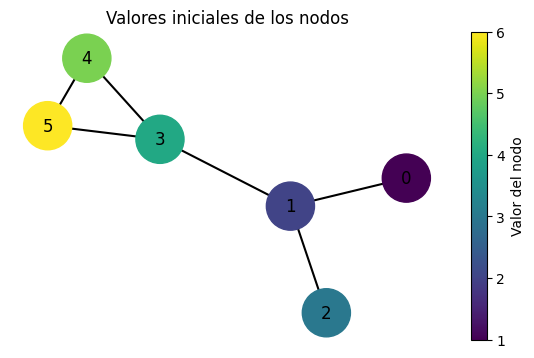

In [18]:
pos_mp = dibujar_grafo_con_valores(
    G,
    H0.flatten(),
    "Valores iniciales de los nodos",
    pos=pos
)

### **5.2. Matriz de adyacencia con auto-conexiones**


Para que cada nodo también conserve parte de su propia información, agregamos auto-conexiones.

Esto equivale a sumar la matriz identidad:

$$
A_{self} = A + I
$$

Así, cada nodo se considera vecino de sí mismo.

In [19]:
A = nx.to_numpy_array(G, nodelist=nodos, dtype=float)

I = np.eye(A.shape[0])

A_self = A + I

A_self_df = pd.DataFrame(
    A_self,
    index=[f"Nodo {i}" for i in nodos],
    columns=[f"Nodo {i}" for i in nodos]
)

display(A_self_df)

,Nodo 0,Nodo 1,Nodo 2,Nodo 3,Nodo 4,Nodo 5
Nodo 0,1.0,1.0,0.0,0.0,0.0,0.0
Nodo 1,1.0,1.0,1.0,1.0,0.0,0.0
Nodo 2,0.0,1.0,1.0,0.0,0.0,0.0
Nodo 3,0.0,1.0,0.0,1.0,1.0,1.0
Nodo 4,0.0,0.0,0.0,1.0,1.0,1.0
Nodo 5,0.0,0.0,0.0,1.0,1.0,1.0


In [20]:
fig = px.imshow(
    A_self_df,
    text_auto=".0f",
    title="Matriz de adyacencia con auto-conexiones",
    color_continuous_scale="Tealgrn",
    labels=dict(x="Nodo destino", y="Nodo origen", color="Conexión")
)

fig.update_layout(
    width=550,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **5.3. Matriz de agregación promedio**

Ahora normalizamos la matriz para que cada nodo calcule el promedio de la información recibida.

La regla será:

$$
\tilde{A}_{ij} = \frac{A_{self}[i,j]}{\text{grado del nodo } i}
$$

Esto evita que los nodos con más vecinos acumulen valores demasiado grandes.

In [21]:
degree = A_self.sum(axis=1, keepdims=True)
degree

array([[2.],
       [4.],
       [2.],
       [4.],
       [3.],
       [3.]])

In [22]:
A_mean = A_self / degree
A_mean

array([[0.5       , 0.5       , 0.        , 0.        , 0.        ,
        0.        ],
       [0.25      , 0.25      , 0.25      , 0.25      , 0.        ,
        0.        ],
       [0.        , 0.5       , 0.5       , 0.        , 0.        ,
        0.        ],
       [0.        , 0.25      , 0.        , 0.25      , 0.25      ,
        0.25      ],
       [0.        , 0.        , 0.        , 0.33333333, 0.33333333,
        0.33333333],
       [0.        , 0.        , 0.        , 0.33333333, 0.33333333,
        0.33333333]])

In [23]:
A_mean_df = pd.DataFrame(
    A_mean,
    index=[f"Nodo {i}" for i in nodos],
    columns=[f"Nodo {i}" for i in nodos]
)

display(A_mean_df.round(2))

,Nodo 0,Nodo 1,Nodo 2,Nodo 3,Nodo 4,Nodo 5
Nodo 0,0.50,0.50,0.00,0.00,0.00,0.00
Nodo 1,0.25,0.25,0.25,0.25,0.00,0.00
Nodo 2,0.00,0.50,0.50,0.00,0.00,0.00
Nodo 3,0.00,0.25,0.00,0.25,0.25,0.25
Nodo 4,0.00,0.00,0.00,0.33,0.33,0.33
Nodo 5,0.00,0.00,0.00,0.33,0.33,0.33


In [24]:
fig = px.imshow(
    A_mean_df,
    text_auto=".2f",
    title="Matriz de agregación promedio",
    color_continuous_scale="Tealgrn",
    labels=dict(x="Nodo vecino", y="Nodo actualizado", color="Peso")
)

fig.update_layout(
    width=550,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **5.4. Una ronda de message passing**

Aplicamos una ronda de propagación:

$$
H^{(1)} = \tilde{A}H^{(0)}
$$

Cada nodo reemplaza su valor original por el promedio entre su valor y los valores de sus vecinos.

In [25]:
H1 = A_mean @ H0

message_passing_df = pd.DataFrame({
    "Nodo": nodos,
    "Feature inicial H0": H0.flatten(),
    "Feature después de message passing H1": H1.flatten()
})

display(message_passing_df.round(3))

,Nodo,Feature inicial H0,Feature después de message passing H1
0,0,1.0,1.50
1,1,2.0,2.50
2,2,3.0,2.50
3,3,4.0,4.25
4,4,5.0,5.00
5,5,6.0,5.00


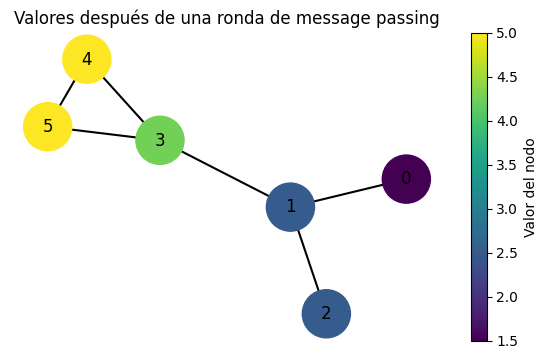

{0: array([ 1.        , -0.04608619]),
 1: array([ 0.37925396, -0.20618831]),
 2: array([ 0.57172744, -0.81572978]),
 3: array([-0.31930738,  0.17563358]),
 4: array([-0.71093448,  0.63901955]),
 5: array([-0.92073954,  0.25335116])}

In [26]:
dibujar_grafo_con_valores(
    G,
    H1.flatten(),
    "Valores después de una ronda de message passing",
    pos=pos_mp
)

### **5.5. Comparación antes y después**

La siguiente tabla muestra cómo cambió la representación de cada nodo.

La interpretación es importante:

- Los nodos ya no conservan solo su información original.
- Ahora contienen información mezclada de sus vecinos.
- Este es el principio que usan las GNN para aprender sobre datos conectados.

In [27]:
comparacion_df = pd.DataFrame({
    "Nodo": nodos,
    "Antes H0": H0.flatten(),
    "Después H1": H1.flatten(),
    "Cambio": (H1 - H0).flatten()
})

display(comparacion_df.round(3))

,Nodo,Antes H0,Después H1,Cambio
0,0,1.0,1.50,0.50
1,1,2.0,2.50,0.50
2,2,3.0,2.50,-0.50
3,3,4.0,4.25,0.25
4,4,5.0,5.00,0.00
5,5,6.0,5.00,-1.00


In [28]:
comparacion_larga_df = comparacion_df.melt(
    id_vars="Nodo",
    value_vars=["Antes H0", "Después H1"],
    var_name="Estado",
    value_name="Feature"
)

fig = px.bar(
    comparacion_larga_df,
    x="Nodo",
    y="Feature",
    color="Estado",
    barmode="group",
    title="Comparación de features antes y después del message passing",
    text_auto=".2f"
)

fig.update_layout(
    width=650,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **5.6. Dos rondas de message passing**

Si aplicamos otra ronda, cada nodo recibe información de vecinos más lejanos.

- Una ronda: vecinos directos.
- Dos rondas: vecinos de vecinos.

Esto ayuda a entender por qué una GCN suele tener varias capas.

In [29]:
H2 = A_mean @ H1

rondas_df = pd.DataFrame({
    "Nodo": nodos,
    "H0 inicial": H0.flatten(),
    "H1 una ronda": H1.flatten(),
    "H2 dos rondas": H2.flatten()
})

display(rondas_df.round(3))

,Nodo,H0 inicial,H1 una ronda,H2 dos rondas
0,0,1.0,1.50,2.000
1,1,2.0,2.50,2.688
2,2,3.0,2.50,2.500
3,3,4.0,4.25,4.188
4,4,5.0,5.00,4.750
5,5,6.0,5.00,4.750


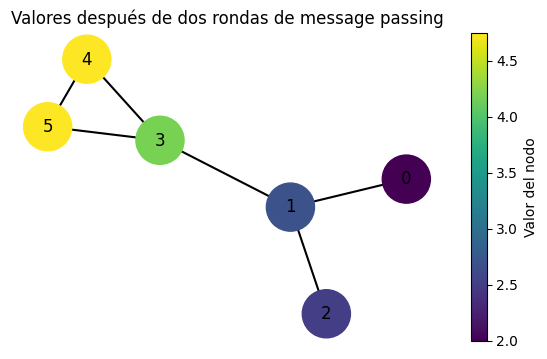

{0: array([ 1.        , -0.04608619]),
 1: array([ 0.37925396, -0.20618831]),
 2: array([ 0.57172744, -0.81572978]),
 3: array([-0.31930738,  0.17563358]),
 4: array([-0.71093448,  0.63901955]),
 5: array([-0.92073954,  0.25335116])}

In [30]:
dibujar_grafo_con_valores(
    G,
    H2.flatten(),
    "Valores después de dos rondas de message passing",
    pos=pos_mp
)

In [31]:
comparacion_2_df = pd.DataFrame({
    "Nodo": nodos,
    "H0": H0.flatten(),
    "H1": H1.flatten(),
    "H2": H2.flatten(),
    "Cambio H1 - H0": (H1 - H0).flatten(),
    "Cambio H2 - H1": (H2 - H1).flatten(),
    "Cambio H2 - H0": (H2 - H0).flatten()
})

display(comparacion_2_df.round(3))

,Nodo,H0,H1,H2,Cambio H1 - H0,Cambio H2 - H1,Cambio H2 - H0
0,0,1.0,1.50,2.000,0.50,0.500,1.000
1,1,2.0,2.50,2.688,0.50,0.188,0.688
2,2,3.0,2.50,2.500,-0.50,0.000,-0.500
3,3,4.0,4.25,4.188,0.25,-0.062,0.188
4,4,5.0,5.00,4.750,0.00,-0.250,-0.250
5,5,6.0,5.00,4.750,-1.00,-0.250,-1.250


In [32]:
comparacion_larga_df = comparacion_2_df.melt(
    id_vars="Nodo",
    value_vars=["H0", "H1", "H2", "Cambio H2 - H0"],
    var_name="Estado",
    value_name="Feature"
)

fig = px.bar(
    comparacion_larga_df,
    x="Nodo",
    y="Feature",
    color="Estado",
    barmode="group",
    title="Comparación de features antes y después del message passing",
    text_auto=".2f"
)

fig.update_layout(
    width=850,
    height=650,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **5.7. Interpretación**



Este ejemplo no es todavía una GCN completa, pero muestra su idea principal.

Una GCN real hace algo similar, pero además aprende parámetros entrenables:

$$
H^{(l+1)} = \sigma(\tilde{A}H^{(l)}W^{(l)})
$$

donde:

- $\tilde{A}$ propaga información entre vecinos;
- $H^{(l)}$ representa las features en la capa actual;
- $W^{(l)}$ son pesos aprendidos por la red neuronal;
- $\sigma$ es una función de activación.

En resumen:

> Una GNN aprende actualizando cada nodo con información de su vecindario.

## **6. Carga del dataset Cora**

Ahora pasamos de los ejemplos pequeños a un dataset real usado frecuentemente en Graph Neural Networks: **Cora**.

Cora es una red de citaciones científicas:

- cada nodo representa un artículo científico;
- cada arista representa una relación de citación;
- cada nodo tiene un vector de características;
- cada nodo tiene una clase temática;
- la tarea consiste en clasificar los nodos.

En este notebook usaremos Cora para comparar:

- **MLP:** usa solo atributos de nodos;
- **GCN:** usa atributos de nodos y relaciones del grafo.

#### **Fijar semilla y dispositivo**

In [33]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dispositivo usado: {device}")

Dispositivo usado: cpu


#### **Cargar Cora**

In [34]:
dataset = Planetoid(
    root="data/Cora",
    name="Cora",
    transform=T.NormalizeFeatures()
)

data = dataset[0].to(device)

Processing...
Done!


In [35]:
print(dataset)
print(data)

Cora()
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


### **6.1. ¿Qué contiene `data`? y ¿Qué representan las features de Cora?**

En PyTorch Geometric, un grafo se representa mediante un objeto `Data`.

En este caso, los elementos principales son:

- `data.x`: matriz de características de los nodos;
- `data.edge_index`: lista de aristas del grafo;
- `data.y`: clase real de cada nodo;
- `data.train_mask`: nodos usados para entrenamiento;
- `data.val_mask`: nodos usados para validación;
- `data.test_mask`: nodos usados para prueba.

In [36]:
data.x

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [37]:
data.edge_index

tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
        [   0,    0,    0,  ..., 2707, 2707, 2707]])

In [38]:
data.y

tensor([3, 4, 4,  ..., 3, 3, 3])

In [39]:
data.train_mask

tensor([ True,  True,  True,  ..., False, False, False])

In [40]:
data.val_mask

tensor([False, False, False,  ..., False, False, False])

In [41]:
data.test_mask

tensor([False, False, False,  ...,  True,  True,  True])

En Cora, cada nodo representa un artículo científico.

La matriz `data.x` tiene dimensión:

$$
2708 \times 1433
$$

Esto significa:

- 2708 nodos, es decir, 2708 artículos científicos.
- 1433 features por nodo.
- Cada feature corresponde a una palabra del vocabulario del corpus.

La representación es de tipo **bag-of-words** o **multi-hot encoding**:

$$
X[i,j] = 1
$$

si la palabra $j$ aparece en el artículo $i$.

$$
X[i,j] = 0
$$

si la palabra $j$ no aparece en el artículo $i$.

Por tanto, las features no son variables como edad, precio o temperatura. Son indicadores de presencia o ausencia de palabras en cada artículo.

In [42]:
# Tomamos una pequeña muestra de nodos y features para visualizar la matriz X.
nodos_muestra = [0, 1, 2, 3, 4]
features_muestra = list(range(15))

x_muestra_df = pd.DataFrame(
    data.x[nodos_muestra, :][:, features_muestra].detach().cpu().numpy(),
    index=[f"Paper/Nodo {i}" for i in nodos_muestra],
    columns=[f"Palabra/Feature {j}" for j in features_muestra]
)

display(x_muestra_df)

,Palabra/Feature 0,Palabra/Feature 1,Palabra/Feature 2,Palabra/Feature 3,Palabra/Feature 4,Palabra/Feature 5,Palabra/Feature 6,Palabra/Feature 7,Palabra/Feature 8,Palabra/Feature 9,Palabra/Feature 10,Palabra/Feature 11,Palabra/Feature 12,Palabra/Feature 13,Palabra/Feature 14
Paper/Nodo 0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Paper/Nodo 1,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Paper/Nodo 2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Paper/Nodo 3,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Paper/Nodo 4,0.0,0.0,0.0,0.055556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


En esta tabla:

- cada fila es un paper;
- cada columna es una palabra del vocabulario;
- un valor distinto de cero indica que esa palabra está presente en el paper;
- un valor igual a cero indica que esa palabra no aparece.

Como usamos `NormalizeFeatures()`, los valores pueden aparecer normalizados y no necesariamente como 0 o 1 puros.

#### **Resumen general del dataset**

In [43]:
resumen_cora_df = pd.DataFrame({
    "Elemento": [
        "Número de grafos",
        "Número de nodos",
        "Número de aristas",
        "Características por nodo",
        "Número de clases",
        "Nodos de entrenamiento",
        "Nodos de validación",
        "Nodos de prueba",
        "¿Grafo no dirigido?"
    ],
    "Valor": [
        len(dataset),
        data.num_nodes,
        data.num_edges,
        dataset.num_node_features,
        dataset.num_classes,
        int(data.train_mask.sum()),
        int(data.val_mask.sum()),
        int(data.test_mask.sum()),
        data.is_undirected()
    ]
})

display(resumen_cora_df)

,Elemento,Valor
0,Número de grafos,1
1,Número de nodos,2708
2,Número de aristas,10556
3,Características por nodo,1433
4,Número de clases,7
5,Nodos de entrenamiento,140
6,Nodos de validación,500
7,Nodos de prueba,1000
8,¿Grafo no dirigido?,True


### **6.2. Tensores principales**

El modelo no recibe directamente una imagen del grafo. Recibe tensores:

- `data.x` contiene los atributos de los nodos;
- `data.edge_index` contiene las conexiones;
- `data.y` contiene las etiquetas.

Esta estructura permite entrenar modelos que usan tanto información individual de cada nodo como relaciones entre nodos.

#### **Dimensiones de los tensores**

In [44]:
tensores_cora_df = pd.DataFrame({
    "Tensor": [
        "data.x",
        "data.edge_index",
        "data.y",
        "data.train_mask",
        "data.val_mask",
        "data.test_mask"
    ],
    "Descripción": [
        "Matriz de características de nodos",
        "Lista de aristas en formato COO",
        "Etiqueta de clase por nodo",
        "Máscara de nodos para entrenamiento",
        "Máscara de nodos para validación",
        "Máscara de nodos para prueba"
    ],
    "Dimensión": [
        str(tuple(data.x.shape)),
        str(tuple(data.edge_index.shape)),
        str(tuple(data.y.shape)),
        str(tuple(data.train_mask.shape)),
        str(tuple(data.val_mask.shape)),
        str(tuple(data.test_mask.shape))
    ]
})

display(tensores_cora_df)

,Tensor,Descripción,Dimensión
0,data.x,Matriz de características de nodos,"(2708, 1433)"
1,data.edge_index,Lista de aristas en formato COO,"(2, 10556)"
2,data.y,Etiqueta de clase por nodo,"(2708,)"
3,data.train_mask,Máscara de nodos para entrenamiento,"(2708,)"
4,data.val_mask,Máscara de nodos para validación,"(2708,)"
5,data.test_mask,Máscara de nodos para prueba,"(2708,)"


#### **Mostrar una muestra de edge_index**

In [45]:
edge_sample_df = pd.DataFrame({
    "Nodo origen": data.edge_index[0, :10].cpu().numpy(),
    "Nodo destino": data.edge_index[1, :10].cpu().numpy()
})

display(edge_sample_df)

,Nodo origen,Nodo destino
0,633,0
1,1862,0
2,2582,0
3,2,1
4,652,1
5,654,1
6,1,2
7,332,2
8,1454,2
9,1666,2


### **6.3. Matriz de características `X`**

La matriz `data.x` tiene una fila por nodo y una columna por característica.

En Cora:

$$
X \in \mathbb{R}^{2708 \times 1433}
$$

Esto significa que cada artículo está representado por un vector de 1433 características.

#### **Visualizar una parte de `data.x`**

In [46]:
x_sample = data.x[:30, :40].detach().cpu().numpy()

fig = px.imshow(
    x_sample,
    title="Muestra de la matriz de características X en Cora",
    labels=dict(x="Feature", y="Nodo", color="Valor"),
    color_continuous_scale="Tealgrn"
)

fig.update_layout(
    width=650,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **6.4. Distribución de clases**

Cada nodo tiene una etiqueta en `data.y`.

En este dataset, la tarea es predecir la clase temática de cada artículo.

In [47]:
clases, conteos = torch.unique(data.y.cpu(), return_counts=True)

clases_df = pd.DataFrame({
    "Clase": clases.numpy(),
    "Cantidad de nodos": conteos.numpy()
})

display(clases_df)

fig = px.bar(
    clases_df,
    x="Clase",
    y="Cantidad de nodos",
    title="Distribución de clases en Cora",
    text="Cantidad de nodos"
)

fig.update_layout(
    width=650,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

,Clase,Cantidad de nodos
0,0,351
1,1,217
2,2,418
3,3,818
4,4,426
5,5,298
6,6,180


### **6.5. Distribución train / validation / test**

Cora ya incluye máscaras para separar los nodos usados en:

- entrenamiento;
- validación;
- prueba.

Esto es importante porque el modelo no se entrena con todos los nodos etiquetados.

#### **Distribución de máscaras**

In [48]:
split_df = pd.DataFrame({
    "Conjunto": ["Train", "Validation", "Test"],
    "Cantidad de nodos": [
        int(data.train_mask.sum()),
        int(data.val_mask.sum()),
        int(data.test_mask.sum())
    ]
})

display(split_df)

fig = px.bar(
    split_df,
    x="Conjunto",
    y="Cantidad de nodos",
    title="Distribución de nodos por conjunto",
    text="Cantidad de nodos"
)

fig.update_layout(
    width=600,
    height=420,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

,Conjunto,Cantidad de nodos
0,Train,140
1,Validation,500
2,Test,1000


### **6.6. Conversión de un subgrafo de Cora a NetworkX**

Cora completo tiene muchos nodos y aristas, por lo que visualizar todo el grafo puede ser poco claro.

Por eso, se selecciona un subgrafo pequeño para mostrar una parte de la red de citaciones.

#### **Construir subgrafo pequeño**

In [49]:
from torch_geometric.utils import k_hop_subgraph

max_nodes = 80

grados = torch.bincount(
    data.edge_index[0].detach().cpu(),
    minlength=data.num_nodes
)

nodo_central = int(torch.argmax(grados).item())

subset, _, _, _ = k_hop_subgraph(
    node_idx=nodo_central,
    num_hops=2,
    edge_index=data.edge_index.detach().cpu(),
    relabel_nodes=False
)

subset_set = set(int(n) for n in subset.tolist())
edge_index_np = data.edge_index.detach().cpu().numpy()

G_temp = nx.Graph()
G_temp.add_nodes_from(subset_set)

for source, target in edge_index_np.T:
    source = int(source)
    target = int(target)

    if source in subset_set and target in subset_set:
        G_temp.add_edge(source, target)

if G_temp.number_of_nodes() > max_nodes:
    selected_nodes = list(nx.bfs_tree(G_temp, source=nodo_central).nodes())[:max_nodes]
    G_cora_small = G_temp.subgraph(selected_nodes).copy()
else:
    G_cora_small = G_temp.copy()

print(f"Nodo central original: {nodo_central}")
print(f"Nodos en subgrafo: {G_cora_small.number_of_nodes()}")
print(f"Aristas en subgrafo: {G_cora_small.number_of_edges()}")
print(f"¿Subgrafo conectado?: {nx.is_connected(G_cora_small)}")

Nodo central original: 1358
Nodos en subgrafo: 80
Aristas en subgrafo: 122
¿Subgrafo conectado?: True


#### **Visualizar subgrafo de Cora**

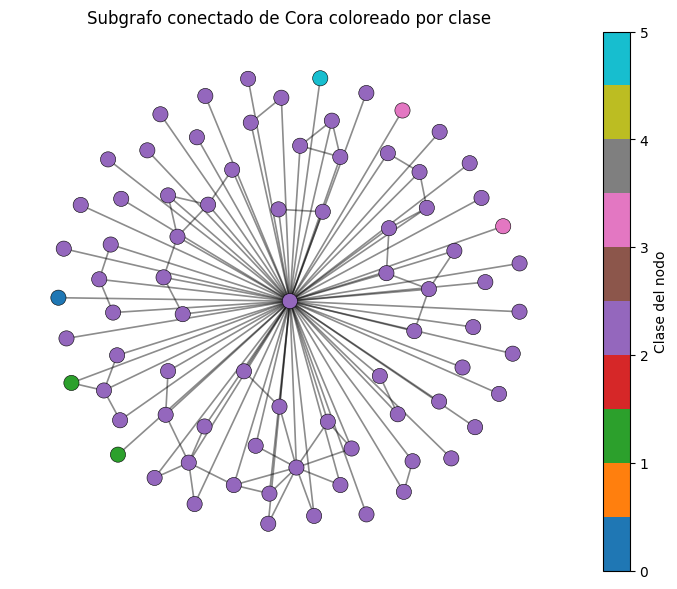

In [50]:
pos_cora = nx.spring_layout(
    G_cora_small,
    seed=42,
    k=0.45,
    iterations=100
)

node_classes = [
    int(data.y[node].detach().cpu())
    for node in G_cora_small.nodes()
]

fig, ax = plt.subplots(figsize=(9, 7))

nx.draw_networkx_edges(
    G_cora_small,
    pos_cora,
    width=1.2,
    alpha=0.45,
    ax=ax
)

nodes = nx.draw_networkx_nodes(
    G_cora_small,
    pos_cora,
    node_color=node_classes,
    node_size=120,
    cmap="tab10",
    edgecolors="black",
    linewidths=0.4,
    ax=ax
)

fig.colorbar(nodes, ax=ax, label="Clase del nodo")

ax.set_title("Subgrafo conectado de Cora coloreado por clase")
ax.axis("off")

plt.show()

### **6.7. Interpretación**

En esta sección ya tenemos los elementos necesarios para entrenar modelos:

- `data.x`: lo usará el MLP y la GCN;
- `data.edge_index`: lo usará solamente la GCN;
- `data.y`: etiquetas reales para calcular la pérdida;
- `train_mask`, `val_mask`, `test_mask`: separación de nodos para entrenamiento, validación y prueba.

La comparación principal será:

| Modelo | Usa `data.x` | Usa `data.edge_index` |
|---|---:|---:|
| MLP | Sí | No |
| GCN | Sí | Sí |

## **7. Exploración de Cora**

Antes de entrenar los modelos, exploramos algunas propiedades importantes del dataset Cora.

Esta exploración permite entender:

- Cuántas conexiones tienen los nodos.
- Cómo están distribuidas las clases.
- Qué tan dispersa es la matriz de características.
- Si los nodos conectados suelen pertenecer a la misma clase.
- Cómo se ve un vecindario local dentro del grafo.

Esto es importante porque una GNN depende directamente de la estructura del grafo.

In [51]:
edge_index_cpu = data.edge_index.detach().cpu()
X_cpu = data.x.detach().cpu()
y_cpu = data.y.detach().cpu()

num_nodes = data.num_nodes
num_edges = data.num_edges
num_classes = dataset.num_classes

print(f"Nodos: {num_nodes}")
print(f"Aristas: {num_edges}")
print(f"Clases: {num_classes}")
print(f"Features por nodo: {dataset.num_node_features}")

Nodos: 2708
Aristas: 10556
Clases: 7
Features por nodo: 1433


### **7.1. Distribución de grados**

El grado de un nodo indica cuántas conexiones tiene.

En una red de citaciones, un nodo con mayor grado está conectado con más artículos.

#### **Calcular grados**

In [52]:
degrees = torch.bincount(edge_index_cpu[0], minlength=num_nodes)

degree_stats_df = pd.DataFrame({
    "Métrica": ["Mínimo", "Máximo", "Promedio", "Mediana"],
    "Valor": [
        int(degrees.min()),
        int(degrees.max()),
        float(degrees.float().mean()),
        float(degrees.float().median())
    ]
})

display(degree_stats_df)

,Métrica,Valor
0,Mínimo,1.00000
1,Máximo,168.00000
2,Promedio,3.89808
3,Mediana,3.00000


#### **Histograma de grados**

In [53]:
degree_df = pd.DataFrame({
    "Nodo": np.arange(num_nodes),
    "Grado": degrees.numpy(),
    "Clase": y_cpu.numpy()
})

fig = px.histogram(
    degree_df,
    x="Grado",
    nbins=50,
    title="Distribución de grados en Cora",
    labels={"Grado": "Grado del nodo", "count": "Cantidad de nodos"}
)

fig.update_layout(
    width=650,
    height=420,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

#### **Nodos con mayor grado**

In [54]:
top_degree_df = degree_df.sort_values("Grado", ascending=False).head(10)

display(top_degree_df)

,Nodo,Grado,Clase
1358,1358,168,2
306,306,78,1
1701,1701,74,3
1986,1986,65,3
1810,1810,44,3
1623,1623,42,1
2034,2034,40,4
88,88,36,0
1013,1013,34,0
598,598,33,3


### **7.2. Sparsity de la matriz de características**

La matriz `data.x` contiene las características de los nodos.

En Cora, cada nodo tiene muchas características, pero normalmente solo una parte pequeña tiene valores diferentes de cero.

Esto significa que la matriz es dispersa.

#### **Calcular valores no nulos por nodo**

In [55]:
nonzero_features = (X_cpu != 0).sum(dim=1)

sparsity_df = pd.DataFrame({
    "Nodo": np.arange(num_nodes),
    "Features no cero": nonzero_features.numpy(),
    "Clase": y_cpu.numpy()
})

sparsity_stats_df = pd.DataFrame({
    "Métrica": ["Mínimo", "Máximo", "Promedio", "Mediana"],
    "Valor": [
        int(nonzero_features.min()),
        int(nonzero_features.max()),
        float(nonzero_features.float().mean()),
        float(nonzero_features.float().median())
    ]
})

display(sparsity_stats_df)

,Métrica,Valor
0,Mínimo,1.000000
1,Máximo,30.000000
2,Promedio,18.174299
3,Mediana,20.000000


#### **Histograma de features activas**

In [56]:
fig = px.histogram(
    sparsity_df,
    x="Features no cero",
    nbins=50,
    title="Cantidad de features no cero por nodo",
    labels={"Features no cero": "Features activas", "count": "Cantidad de nodos"}
)

fig.update_layout(
    width=650,
    height=420,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **7.3. Distribución de clases por conjunto**

Cora ya trae una división en entrenamiento, validación y prueba.

Vamos a revisar cuántos nodos de cada clase hay en cada conjunto.

#### **Tabla clase vs split**

In [57]:
masks = {
    "Train": data.train_mask.detach().cpu(),
    "Validation": data.val_mask.detach().cpu(),
    "Test": data.test_mask.detach().cpu()
}

split_class_rows = []

for split_name, mask in masks.items():
    y_split = y_cpu[mask]
    classes, counts = torch.unique(y_split, return_counts=True)

    for cls, count in zip(classes.numpy(), counts.numpy()):
        split_class_rows.append({
            "Conjunto": split_name,
            "Clase": int(cls),
            "Cantidad": int(count)
        })

split_class_df = pd.DataFrame(split_class_rows)

display(split_class_df)

,Conjunto,Clase,Cantidad
0,Train,0,20
1,Train,1,20
2,Train,2,20
3,Train,3,20
4,Train,4,20
5,Train,5,20
6,Train,6,20
7,Validation,0,61
8,Validation,1,36
9,Validation,2,78


#### **Gráfico de clases por split**

In [58]:
fig = px.bar(
    split_class_df,
    x="Clase",
    y="Cantidad",
    color="Conjunto",
    barmode="group",
    title="Distribución de clases por conjunto",
    text="Cantidad"
)

fig.update_layout(
    width=700,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **7.4. Homofilia del grafo**

La homofilia mide qué tanto los nodos conectados tienden a pertenecer a la misma clase.

En clasificación de nodos, esto es importante porque muchas GNN funcionan mejor cuando los vecinos de un nodo tienen etiquetas o patrones similares.

De forma simple:

$$
\text{Homofilia} = \frac{\text{Aristas que conectan nodos de la misma clase}}{\text{Total de aristas}}
$$

#### **Calcular homofilia**

In [59]:
edges = edge_index_cpu.T.numpy()

edges_sorted = np.sort(edges, axis=1)
edges_unique = np.unique(edges_sorted, axis=0)

same_class = []

for source, target in edges_unique:
    same_class.append(int(y_cpu[source]) == int(y_cpu[target]))

homophily = np.mean(same_class)

homophily_df = pd.DataFrame({
    "Métrica": [
        "Aristas únicas",
        "Aristas misma clase",
        "Homofilia"
    ],
    "Valor": [
        len(edges_unique),
        int(np.sum(same_class)),
        round(float(homophily), 4)
    ]
})

display(homophily_df)

,Métrica,Valor
0,Aristas únicas,5278.00
1,Aristas misma clase,4275.00
2,Homofilia,0.81


#### **Gráfico homofilia**

In [60]:
homophily_plot_df = pd.DataFrame({
    "Tipo de conexión": ["Misma clase", "Distinta clase"],
    "Cantidad": [
        int(np.sum(same_class)),
        int(len(same_class) - np.sum(same_class))
    ]
})

fig = px.pie(
    homophily_plot_df,
    names="Tipo de conexión",
    values="Cantidad",
    title="Proporción de conexiones según clase"
)

fig.update_layout(
    width=600,
    height=420,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **7.5. Vecindario de un nodo**

Ahora observamos el vecindario de un nodo con alto grado.

Esto permite ver de manera local qué información podría recibir un nodo durante el message passing.

#### **Seleccionar nodo con alto grado**

In [61]:
nodo_central = int(torch.argmax(degrees).item())

neighbors = edge_index_cpu[1][edge_index_cpu[0] == nodo_central].unique()

vecindario_df = pd.DataFrame({
    "Nodo": [nodo_central] + neighbors.numpy().tolist(),
    "Tipo": ["Central"] + ["Vecino"] * len(neighbors),
    "Clase": [int(y_cpu[nodo_central])] + [int(y_cpu[n]) for n in neighbors]
})

display(vecindario_df.head(20))

print(f"Nodo central: {nodo_central}")
print(f"Grado del nodo central: {int(degrees[nodo_central])}")
print(f"Número de vecinos únicos: {len(neighbors)}")

,Nodo,Tipo,Clase
0,1358,Central,2
1,30,Vecino,3
2,34,Vecino,2
3,53,Vecino,2
4,59,Vecino,2
5,68,Vecino,2
6,72,Vecino,2
7,73,Vecino,2
8,90,Vecino,2
9,101,Vecino,2


Nodo central: 1358
Grado del nodo central: 168
Número de vecinos únicos: 168


#### **Visualizar vecindario**

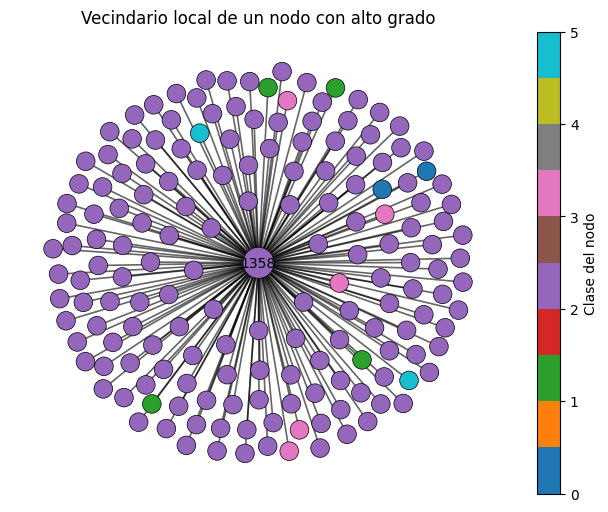

In [62]:
G_ego = nx.Graph()

G_ego.add_node(nodo_central)

for neighbor in neighbors.numpy():
    G_ego.add_edge(nodo_central, int(neighbor))

pos_ego = nx.spring_layout(G_ego, seed=42)

node_colors = [
    int(y_cpu[node])
    for node in G_ego.nodes()
]

node_sizes = [
    500 if node == nodo_central else 180
    for node in G_ego.nodes()
]

fig, ax = plt.subplots(figsize=(8, 6))

nx.draw_networkx_edges(
    G_ego,
    pos_ego,
    width=1.2,
    alpha=0.6,
    ax=ax
)

nodes = nx.draw_networkx_nodes(
    G_ego,
    pos_ego,
    node_color=node_colors,
    node_size=node_sizes,
    cmap="tab10",
    edgecolors="black",
    linewidths=0.5,
    ax=ax
)

nx.draw_networkx_labels(
    G_ego,
    pos_ego,
    labels={nodo_central: str(nodo_central)},
    font_size=10,
    ax=ax
)

fig.colorbar(nodes, ax=ax, label="Clase del nodo")

ax.set_title("Vecindario local de un nodo con alto grado")
ax.axis("off")

plt.show()

### **7.6. Matriz de adyacencia de un subgrafo**


Para visualizar una matriz de adyacencia de forma clara, usamos un subgrafo pequeño.

Esta matriz muestra qué nodos del subgrafo están conectados entre sí.

In [63]:
selected_nodes = list(G_cora_small.nodes())[:30]

G_adj_small = G_cora_small.subgraph(selected_nodes).copy()

A_cora_small = nx.to_numpy_array(
    G_adj_small,
    nodelist=selected_nodes,
    dtype=int
)

A_cora_small_df = pd.DataFrame(
    A_cora_small,
    index=[f"Nodo {i}" for i in selected_nodes],
    columns=[f"Nodo {i}" for i in selected_nodes]
)

display(A_cora_small_df)

,Nodo 524,Nodo 1038,Nodo 1040,Nodo 1041,Nodo 30,Nodo 34,Nodo 552,Nodo 1070,Nodo 1072,Nodo 53,...,Nodo 613,Nodo 616,Nodo 111,Nodo 626,Nodo 1145,Nodo 1149,Nodo 1154,Nodo 645,Nodo 1169,Nodo 154
Nodo 524,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
Nodo 1038,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nodo 1040,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
Nodo 1041,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nodo 30,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nodo 34,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Nodo 552,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
Nodo 1070,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Nodo 1072,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Nodo 53,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### **Heatmap matriz de adyacencia del subgrafo**

In [64]:
fig = px.imshow(
    A_cora_small_df,
    text_auto=False,
    title="Matriz de adyacencia de un subgrafo de Cora",
    color_continuous_scale="Tealgrn",
    labels=dict(x="Nodo destino", y="Nodo origen", color="Conexión")
)

fig.update_layout(
    width=650,
    height=600,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **7.7. Interpretación de la exploración**

A partir de esta exploración se pueden destacar varias ideas:

1. Cora es un grafo de citaciones con nodos, aristas, atributos y etiquetas.
2. Los nodos no tienen el mismo número de conexiones.
3. La matriz de características es de alta dimensión y dispersa.
4. Las máscaras `train`, `validation` y `test` permiten evaluar el modelo sin entrenar sobre todos los nodos.
5. La homofilia indica si los nodos conectados tienden a compartir clase.
6. La GCN aprovechará `data.edge_index`, mientras que el MLP solo usará `data.x`.

La siguiente sección compara ambos enfoques:

| Modelo | Usa características `data.x` | Usa aristas `data.edge_index` |
|---|---:|---:|
| MLP | Sí | No |
| GCN | Sí | Sí |

### **Nota Final**

En Cora, cada nodo es un paper. Cada paper está representado por un vector de 1433 posiciones. Cada posición representa una palabra del vocabulario. Si una palabra aparece en el paper, esa feature se activa. Además, los papers están conectados por citaciones. Entonces el MLP solo usa las palabras del paper, mientras que la GCN usa las palabras y también la red de citaciones.

## **8. Modelo MLP base**

Antes de entrenar una Graph Neural Network, usaremos un modelo base tipo **MLP (Multilayer perceptron)**.

El objetivo del MLP es clasificar los nodos usando únicamente sus características:

$$
X = \text{data.x}
$$

Este modelo **no usa** la estructura del grafo:

$$
\text{edge\_index}
$$

Por tanto, el MLP sirve como referencia para comparar si la GCN realmente mejora al usar las relaciones entre nodos.

### **8.1. Idea del modelo MLP**

En Cora:

- Cada nodo es un artículo científico.
- Cada nodo tiene un vector de 1433 features.
- Cada feature representa una palabra del vocabulario.
- El MLP intenta predecir la clase del artículo usando solo ese vector.

La entrada del MLP será:

$$
X \in \mathbb{R}^{2708 \times 1433}
$$

La salida será una predicción para cada una de las 7 clases.

In [65]:
from copy import deepcopy

INPUT_DIM = dataset.num_node_features
HIDDEN_DIM = 16
OUTPUT_DIM = dataset.num_classes

LEARNING_RATE = 0.01
WEIGHT_DECAY = 5e-4
DROPOUT = 0.5
EPOCHS = 200

print(f"Input dim: {INPUT_DIM}")
print(f"Hidden dim: {HIDDEN_DIM}")
print(f"Output dim: {OUTPUT_DIM}")

Input dim: 1433
Hidden dim: 16
Output dim: 7


In [66]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super().__init__()

        self.dropout = dropout
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.fc2(x)

        return x

### **8.2. Estructura del MLP**

El modelo tiene dos capas lineales:

$$
1433 \rightarrow 16 \rightarrow 7
$$

Interpretación:

- **1433:** número de features por nodo;
- **16:** dimensión oculta;
- **7:** número de clases del dataset Cora.

Este modelo no recibe información de aristas. Solo procesa cada nodo a partir de sus propias features.

#### **Crear el modelo MLP**

In [67]:
mlp_model = MLP(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    dropout=DROPOUT
).to(device)

mlp_model

MLP(
  (fc1): Linear(in_features=1433, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=7, bias=True)
)

#### **Función de accuracy**

In [68]:
def calcular_accuracy(logits, labels):
    predicciones = logits.argmax(dim=1)
    accuracy = (predicciones == labels).float().mean().item()

    return accuracy

#### **Funciones de entrenamiento y evaluación**

In [69]:
def forward_model(model, data, use_edges=False):
    if use_edges:
        return model(data.x, data.edge_index)

    return model(data.x)

In [70]:
def entrenar_una_epoca(model, data, optimizer, use_edges=False):
    model.train()
    optimizer.zero_grad()

    logits = forward_model(model, data, use_edges=use_edges)
    loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    return loss.item()

In [71]:
@torch.no_grad()
def evaluar_modelo(model, data, use_edges=False):
    model.eval()

    logits = forward_model(model, data, use_edges=use_edges)

    train_acc = calcular_accuracy(logits[data.train_mask], data.y[data.train_mask])
    val_acc = calcular_accuracy(logits[data.val_mask], data.y[data.val_mask])
    test_acc = calcular_accuracy(logits[data.test_mask], data.y[data.test_mask])

    return train_acc, val_acc, test_acc

#### **Función general de entrenamiento**

In [72]:
def entrenar_modelo(model, data, epochs, lr, weight_decay, use_edges=False, nombre_modelo="Modelo"):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_acc = 0.0
    best_test_acc = 0.0
    best_state = None

    history = []

    for epoch in range(1, epochs + 1):
        loss = entrenar_una_epoca(
            model,
            data,
            optimizer,
            use_edges=use_edges
        )

        train_acc, val_acc, test_acc = evaluar_modelo(
            model,
            data,
            use_edges=use_edges
        )

        history.append({
            "Modelo": nombre_modelo,
            "Época": epoch,
            "Loss": loss,
            "Train accuracy": train_acc,
            "Validation accuracy": val_acc,
            "Test accuracy": test_acc
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc
            best_state = deepcopy(model.state_dict())

        if epoch % 20 == 0 or epoch == 1:
            print(
                f"{nombre_modelo} | "
                f"Época {epoch:03d} | "
                f"Loss: {loss:.4f} | "
                f"Train: {train_acc:.4f} | "
                f"Val: {val_acc:.4f} | "
                f"Test: {test_acc:.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    results = {
        "Modelo": nombre_modelo,
        "Best validation accuracy": best_val_acc,
        "Best test accuracy": best_test_acc
    }

    return model, history_df, results

### **8.3. Entrenamiento del MLP**

Ahora entrenamos el MLP usando solamente:

$$
\text{data.x}
$$

El modelo se evalúa con las máscaras que trae Cora:

- `train_mask`;
- `val_mask`;
- `test_mask`.

La métrica principal será **accuracy**.

#### **Entrenar MLP**

In [73]:
mlp_model, mlp_history_df, mlp_results = entrenar_modelo(
    model=mlp_model,
    data=data,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    use_edges=False,
    nombre_modelo="MLP"
)

MLP | Época 001 | Loss: 1.9521 | Train: 0.1429 | Val: 0.0720 | Test: 0.0910
MLP | Época 020 | Loss: 1.7526 | Train: 1.0000 | Val: 0.5420 | Test: 0.5360
MLP | Época 040 | Loss: 1.3092 | Train: 0.9929 | Val: 0.4880 | Test: 0.4960
MLP | Época 060 | Loss: 0.8732 | Train: 1.0000 | Val: 0.5380 | Test: 0.5420
MLP | Época 080 | Loss: 0.6726 | Train: 1.0000 | Val: 0.5380 | Test: 0.5560
MLP | Época 100 | Loss: 0.5354 | Train: 1.0000 | Val: 0.5480 | Test: 0.5580
MLP | Época 120 | Loss: 0.5545 | Train: 1.0000 | Val: 0.5300 | Test: 0.5450
MLP | Época 140 | Loss: 0.4581 | Train: 1.0000 | Val: 0.5360 | Test: 0.5510
MLP | Época 160 | Loss: 0.5049 | Train: 1.0000 | Val: 0.5320 | Test: 0.5560
MLP | Época 180 | Loss: 0.4709 | Train: 1.0000 | Val: 0.5440 | Test: 0.5650
MLP | Época 200 | Loss: 0.4211 | Train: 1.0000 | Val: 0.5400 | Test: 0.5660


#### **Resultados del MLP**

In [74]:
mlp_results_df = pd.DataFrame([mlp_results])

display(mlp_results_df)

,Modelo,Best validation accuracy,Best test accuracy
0,MLP,0.56,0.556


#### **Historial del MLP**

In [75]:
display(mlp_history_df.tail())

,Modelo,Época,Loss,Train accuracy,Validation accuracy,Test accuracy
195,MLP,196,0.440816,1.0,0.542,0.559
196,MLP,197,0.454378,1.0,0.544,0.563
197,MLP,198,0.429573,1.0,0.544,0.566
198,MLP,199,0.456085,1.0,0.540,0.566
199,MLP,200,0.421074,1.0,0.540,0.566


#### **Curva de pérdida del MLP**

In [76]:
fig = px.line(
    mlp_history_df,
    x="Época",
    y="Loss",
    title="Curva de pérdida - MLP",
    markers=False
)

fig.update_layout(
    width=650,
    height=420,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

#### **Accuracy del MLP**

In [77]:
accuracy_mlp_df = mlp_history_df.melt(
    id_vars=["Modelo", "Época", "Loss"],
    value_vars=["Train accuracy", "Validation accuracy", "Test accuracy"],
    var_name="Conjunto",
    value_name="Accuracy"
)

fig = px.line(
    accuracy_mlp_df,
    x="Época",
    y="Accuracy",
    color="Conjunto",
    title="Accuracy durante el entrenamiento - MLP"
)

fig.update_layout(
    width=700,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **8.4. Interpretación del MLP**

El MLP sirve como modelo base.

Su comportamiento se interpreta así:

- Si obtiene buen desempeño, significa que las features de los nodos contienen información útil.
- Si la GCN mejora frente al MLP, eso sugiere que las conexiones del grafo aportan información adicional.
- Si la GCN no mejora, puede significar que la estructura del grafo no ayuda mucho o que el modelo necesita ajustes.

La comparación importante será:

| Modelo | Usa features `data.x` | Usa aristas `data.edge_index` |
|---|---:|---:|
| MLP | Sí | No |
| GCN | Sí | Sí |

### **8.5. Evidencia de overfitting en el MLP**

El MLP alcanza rápidamente una accuracy de entrenamiento cercana a 1.0.  
Sin embargo, la accuracy de validación y prueba se mantiene alrededor de 0.54 - 0.56.

Esto indica **overfitting**: el modelo memoriza los nodos de entrenamiento, pero no generaliza igual de bien a nodos no vistos.

Este comportamiento es importante para la comparación, porque el MLP solo usa las características de los nodos (`data.x`) y no usa la estructura del grafo (`data.edge_index`).

Por tanto, el MLP funciona como una línea base.  
La pregunta central será si una GCN mejora la generalización al usar también las relaciones de citación entre artículos.

In [78]:
best_mlp_row = mlp_history_df.loc[
    mlp_history_df["Validation accuracy"].idxmax()
]

display(pd.DataFrame([best_mlp_row]))

,Modelo,Época,Loss,Train accuracy,Validation accuracy,Test accuracy
90,MLP,91,0.642271,1.0,0.56,0.556


In [79]:
mlp_overfitting_df = mlp_history_df.copy()

mlp_overfitting_df["Gap Train-Val"] = (
    mlp_overfitting_df["Train accuracy"] -
    mlp_overfitting_df["Validation accuracy"]
)

fig = px.line(
    mlp_overfitting_df,
    x="Época",
    y="Gap Train-Val",
    title="Brecha de overfitting en el MLP",
    labels={
        "Gap Train-Val": "Train accuracy - Validation accuracy"
    }
)

fig.update_layout(
    width=650,
    height=420,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **Nota Final**

“El MLP alcanza accuracy perfecta en entrenamiento muy rápido, pero su
desempeño en validación y prueba queda alrededor de 55%. Esto muestra
overfitting. El modelo aprende muy bien los ejemplos etiquetados, pero
como no usa las conexiones del grafo, no aprovecha la estructura de citaciones.
Por eso ahora comparamos contra una GCN, que sí usa atributos y relaciones.”

## **9. Modelo GCN**

Ahora definimos una **Graph Convolutional Network**.

A diferencia del MLP, la GCN no usa solamente las características de cada nodo. También usa la estructura del grafo mediante:

```python
data.edge_index
````

La idea principal es que cada nodo actualiza su representación usando información de sus vecinos.

En este experimento:

| Modelo | Usa `data.x` | Usa `data.edge_index` |
| ------ | -----------: | --------------------: |
| MLP    |           Sí |                    No |
| GCN    |           Sí |                    Sí |


### **9.1. Idea de una capa GCN**


Una capa GCN combina tres elementos:

1. Las características actuales de los nodos.
2. Las conexiones del grafo.
3. Una transformación neuronal aprendible.

De forma simplificada:

$$
H^{(l+1)} = \sigma(\tilde{A}H^{(l)}W^{(l)})
$$

donde:

- $H^{(l)}$ representa las características en la capa actual.
- $\tilde{A}$ representa la matriz de adyacencia normalizada.
- $W^{(l)}$ son pesos aprendidos.
- $\sigma$ es una función de activación.

En palabras simples: cada nodo aprende combinando su propia información con la de sus vecinos.

#### **Definición del modelo GCN**

In [80]:
class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super().__init__()

        self.dropout = dropout
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)

        return x

### **9.2. Estructura de la GCN**


La arquitectura usada será:

$$
1433 \rightarrow 16 \rightarrow 7
$$

Interpretación:

- **1433:** número de features por nodo;
- **16:** dimensión oculta;
- **7:** número de clases del dataset Cora.

La diferencia frente al MLP está en que cada capa `GCNConv` recibe también las aristas del grafo:

```python
GCNConv(x, edge_index)
````

Por tanto, la predicción de cada nodo depende de sus atributos y de su vecindario.

#### **Crear modelo GCN**

In [81]:
torch.manual_seed(SEED)

gcn_model = GCN(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    dropout=DROPOUT
).to(device)

gcn_model

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)

#### **Verificar una pasada hacia adelante**

In [82]:
gcn_model.eval()

with torch.no_grad():
    logits_gcn = gcn_model(data.x, data.edge_index)

print("Dimensión de salida de la GCN:", logits_gcn.shape)
print("Número de nodos:", data.num_nodes)
print("Número de clases:", dataset.num_classes)

Dimensión de salida de la GCN: torch.Size([2708, 7])
Número de nodos: 2708
Número de clases: 7


La salida de la GCN tiene dimensión:

$$
2708 \times 7
$$

Esto significa que el modelo genera una predicción de clase para cada uno de los 2708 nodos del grafo.

## **10. Entrenamiento y evaluación**

Ahora entrenamos la GCN usando la misma función general de entrenamiento que se usó para el MLP.

La diferencia es que ahora activamos:

```python
use_edges=True
````

Esto indica que el modelo debe recibir tanto:

```python
data.x
data.edge_index
```

La métrica principal será **accuracy** en entrenamiento, validación y prueba.

#### **Entrenar GCN**

In [83]:
gcn_model, gcn_history_df, gcn_results = entrenar_modelo(
    model=gcn_model,
    data=data,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    use_edges=True,
    nombre_modelo="GCN"
)

GCN | Época 001 | Loss: 1.9459 | Train: 0.3214 | Val: 0.1440 | Test: 0.1570
GCN | Época 020 | Loss: 1.7174 | Train: 0.8571 | Val: 0.5260 | Test: 0.5360
GCN | Época 040 | Loss: 1.3281 | Train: 0.9643 | Val: 0.7040 | Test: 0.7030
GCN | Época 060 | Loss: 0.9540 | Train: 0.9929 | Val: 0.7600 | Test: 0.7720
GCN | Época 080 | Loss: 0.6925 | Train: 0.9929 | Val: 0.7760 | Test: 0.7900
GCN | Época 100 | Loss: 0.5591 | Train: 0.9929 | Val: 0.7660 | Test: 0.7950
GCN | Época 120 | Loss: 0.4700 | Train: 0.9929 | Val: 0.7740 | Test: 0.8020
GCN | Época 140 | Loss: 0.4071 | Train: 0.9929 | Val: 0.7780 | Test: 0.8010
GCN | Época 160 | Loss: 0.3849 | Train: 1.0000 | Val: 0.7780 | Test: 0.8010
GCN | Época 180 | Loss: 0.3435 | Train: 1.0000 | Val: 0.7780 | Test: 0.8020
GCN | Época 200 | Loss: 0.3223 | Train: 1.0000 | Val: 0.7800 | Test: 0.7990


#### **Resultados de la GCN**

In [84]:
gcn_results_df = pd.DataFrame([gcn_results])

display(gcn_results_df)

,Modelo,Best validation accuracy,Best test accuracy
0,GCN,0.784,0.806


#### **Historial final de la GCN**

In [85]:
display(gcn_history_df.tail())

,Modelo,Época,Loss,Train accuracy,Validation accuracy,Test accuracy
195,GCN,196,0.306323,1.0,0.776,0.796
196,GCN,197,0.308420,1.0,0.776,0.794
197,GCN,198,0.329003,1.0,0.782,0.796
198,GCN,199,0.369880,1.0,0.782,0.798
199,GCN,200,0.322318,1.0,0.780,0.799


### **10.1. Curva de pérdida de la GCN**

La pérdida muestra cómo cambia el error del modelo durante el entrenamiento.

Si la pérdida baja, significa que el modelo está ajustando sus parámetros para clasificar mejor los nodos de entrenamiento.

#### **Curva de pérdida GCN**

In [86]:
fig = px.line(
    gcn_history_df,
    x="Época",
    y="Loss",
    title="Curva de pérdida - GCN",
    markers=False
)

fig.update_layout(
    width=650,
    height=420,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **10.2. Accuracy durante el entrenamiento**

Ahora visualizamos la evolución del accuracy en:

- entrenamiento;
- validación;
- prueba.

Esta gráfica permite observar si el modelo generaliza mejor que el MLP.

#### **Accuracy GCN**

In [87]:
accuracy_gcn_df = gcn_history_df.melt(
    id_vars=["Modelo", "Época", "Loss"],
    value_vars=["Train accuracy", "Validation accuracy", "Test accuracy"],
    var_name="Conjunto",
    value_name="Accuracy"
)

fig = px.line(
    accuracy_gcn_df,
    x="Época",
    y="Accuracy",
    color="Conjunto",
    title="Accuracy durante el entrenamiento - GCN"
)

fig.update_layout(
    width=700,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5)
)

fig.show(config={"displayModeBar": False})

### **10.3. Mejor época de la GCN**

Para evaluar correctamente, seleccionamos el mejor modelo según **validation accuracy**.

No se debe escoger el modelo mirando directamente el test, porque el conjunto de prueba debe funcionar como evaluación final.

#### **Mejor época según validación**

In [88]:
best_gcn_row = gcn_history_df.loc[
    gcn_history_df["Validation accuracy"].idxmax()
]

display(pd.DataFrame([best_gcn_row]))

,Modelo,Época,Loss,Train accuracy,Validation accuracy,Test accuracy
124,GCN,125,0.471494,0.992857,0.784,0.806


### **10.4. Evidencia de overfitting en la GCN**


La GCN también alcanza una accuracy de entrenamiento cercana a 1.0, lo que indica que el modelo aprende casi perfectamente los nodos usados para entrenamiento.

Sin embargo, a diferencia del MLP, la GCN mantiene una accuracy de validación cercana a 0.78 y una accuracy de prueba cercana a 0.80.

Esto significa que también existe overfitting, pero la generalización es mucho mejor que en el MLP.

La razón principal es que la GCN no usa solamente las características de cada nodo (`data.x`), sino también la estructura del grafo (`data.edge_index`). En Cora, las relaciones de citación entre artículos aportan información útil para clasificar los nodos.

## **11. Comparación MLP vs GCN**

### **11.1. Comparación rápida: MLP vs GCN**

Ahora comparamos el modelo base MLP contra la GCN.

La comparación es importante porque:

- el MLP usa solo las features de los nodos;
- la GCN usa las features y las relaciones del grafo.

Si la GCN mejora frente al MLP, eso sugiere que la estructura de citaciones aporta información útil para clasificar los artículos.

In [89]:
comparacion_resultados_df = pd.DataFrame([
    {
        "Modelo": "MLP",
        "Usa features data.x": "Sí",
        "Usa aristas data.edge_index": "No",
        "Best validation accuracy": mlp_results["Best validation accuracy"],
        "Best test accuracy": mlp_results["Best test accuracy"]
    },
    {
        "Modelo": "GCN",
        "Usa features data.x": "Sí",
        "Usa aristas data.edge_index": "Sí",
        "Best validation accuracy": gcn_results["Best validation accuracy"],
        "Best test accuracy": gcn_results["Best test accuracy"]
    }
])

display(comparacion_resultados_df)

,Modelo,Usa features data.x,Usa aristas data.edge_index,Best validation accuracy,Best test accuracy
0,MLP,Sí,No,0.560,0.556
1,GCN,Sí,Sí,0.784,0.806


#### **Gráfico comparativo MLP vs GCN**

In [90]:
comparacion_plot_df = comparacion_resultados_df.melt(
    id_vars=["Modelo", "Usa features data.x", "Usa aristas data.edge_index"],
    value_vars=["Best validation accuracy", "Best test accuracy"],
    var_name="Métrica",
    value_name="Accuracy"
)

fig = px.bar(
    comparacion_plot_df,
    x="Modelo",
    y="Accuracy",
    color="Métrica",
    barmode="group",
    title="Comparación de desempeño: MLP vs GCN",
    text_auto=".3f"
)

fig.update_layout(
    width=700,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5),
    yaxis=dict(range=[0, 1])
)

fig.show(config={"displayModeBar": False})

### **11.2. Curvas comparadas de validación**


Esta gráfica compara el desempeño de validación del MLP y la GCN durante el entrenamiento.

La validación es útil para observar qué modelo generaliza mejor a nodos no usados para entrenar.

#### **Comparación de validation accuracy**

In [91]:
historial_comparado_df = pd.concat(
    [mlp_history_df, gcn_history_df],
    ignore_index=True
)

fig = px.line(
    historial_comparado_df,
    x="Época",
    y="Validation accuracy",
    color="Modelo",
    title="Validation accuracy: MLP vs GCN"
)

fig.update_layout(
    width=700,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5),
    yaxis=dict(range=[0, 1])
)

fig.show(config={"displayModeBar": False})

#### **Comparación de test accuracy**

In [92]:
fig = px.line(
    historial_comparado_df,
    x="Época",
    y="Test accuracy",
    color="Modelo",
    title="Test accuracy: MLP vs GCN"
)

fig.update_layout(
    width=700,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5),
    yaxis=dict(range=[0, 1])
)

fig.show(config={"displayModeBar": False})

### **11.3. Interpretación preliminar**


La comparación MLP vs GCN permite responder la pregunta central del notebook:

> ¿Aporta información útil la estructura del grafo?

El MLP aprende únicamente desde las features de cada nodo.  
La GCN aprende desde las features y desde las conexiones de citación.

Por eso, si la GCN obtiene mejor desempeño en validación y prueba, se puede interpretar que las relaciones entre artículos ayudan a mejorar la clasificación.

Esta comparación no significa que la GCN siempre sea mejor en cualquier grafo. Su rendimiento depende de la calidad de las relaciones, la homofilia del grafo, la cantidad de datos etiquetados y la configuración del modelo.

## **12. Conclusiones y riesgos**

En este notebook se mostró el flujo básico para entender una Graph Neural Network:

1. Construir grafos simples.
2. Representar grafos mediante matrices de adyacencia.
3. Explicar message passing.
4. Cargar un dataset real de grafos: Cora.
5. Entrenar un modelo MLP base.
6. Entrenar una GCN.
7. Comparar ambos modelos.

La pregunta principal fue:

> ¿Aporta información útil la estructura del grafo para clasificar nodos?

#### **Resumen final de resultados**

In [93]:
resumen_final_df = pd.DataFrame([
    {
        "Modelo": "MLP",
        "Usa atributos de nodos": "Sí",
        "Usa aristas del grafo": "No",
        "Best validation accuracy": mlp_results["Best validation accuracy"],
        "Best test accuracy": mlp_results["Best test accuracy"]
    },
    {
        "Modelo": "GCN",
        "Usa atributos de nodos": "Sí",
        "Usa aristas del grafo": "Sí",
        "Best validation accuracy": gcn_results["Best validation accuracy"],
        "Best test accuracy": gcn_results["Best test accuracy"]
    }
])

display(resumen_final_df.round(4))

,Modelo,Usa atributos de nodos,Usa aristas del grafo,Best validation accuracy,Best test accuracy
0,MLP,Sí,No,0.560,0.556
1,GCN,Sí,Sí,0.784,0.806


#### **Mejora de GCN frente a MLP.**

In [94]:
mejora_val = gcn_results["Best validation accuracy"] - mlp_results["Best validation accuracy"]
mejora_test = gcn_results["Best test accuracy"] - mlp_results["Best test accuracy"]

mejora_df = pd.DataFrame({
    "Comparación": ["GCN - MLP"],
    "Mejora en validation accuracy": [mejora_val],
    "Mejora en test accuracy": [mejora_test]
})

display(mejora_df.round(4))

,Comparación,Mejora en validation accuracy,Mejora en test accuracy
0,GCN - MLP,0.224,0.25


#### **Gráfico final de comparación**

In [95]:
resumen_plot_df = resumen_final_df.melt(
    id_vars=["Modelo", "Usa atributos de nodos", "Usa aristas del grafo"],
    value_vars=["Best validation accuracy", "Best test accuracy"],
    var_name="Métrica",
    value_name="Accuracy"
)

fig = px.bar(
    resumen_plot_df,
    x="Modelo",
    y="Accuracy",
    color="Métrica",
    barmode="group",
    title="Resultado final: MLP vs GCN",
    text_auto=".3f"
)

fig.update_layout(
    width=700,
    height=450,
    margin=dict(l=40, r=40, t=70, b=40),
    title=dict(x=0.5),
    yaxis=dict(range=[0, 1])
)

fig.show(config={"displayModeBar": False})

### **12.1. Conclusión técnica**

El MLP y la GCN usan las mismas características iniciales de los nodos:

$$
X = \text{data.x}
$$

Sin embargo, la diferencia principal es que la GCN también usa la estructura del grafo:

$$
\text{edge_index}
$$

En los resultados obtenidos, el MLP alcanza una accuracy alta en entrenamiento, pero su desempeño en validación y prueba es menor. Esto indica que el modelo aprende muy bien los nodos de entrenamiento, pero generaliza con dificultad.

La GCN también puede presentar overfitting, pero logra una mejor generalización porque aprovecha las relaciones de citación entre artículos.

Por tanto, en este experimento, la estructura del grafo sí aporta información útil para clasificar nodos.

#### **Tabla de overfitting**

In [96]:
overfitting_resumen_df = pd.DataFrame({
    "Modelo": ["MLP", "GCN"],
    "Máximo train accuracy": [
        mlp_history_df["Train accuracy"].max(),
        gcn_history_df["Train accuracy"].max()
    ],
    "Mejor validation accuracy": [
        mlp_results["Best validation accuracy"],
        gcn_results["Best validation accuracy"]
    ],
    "Brecha Train - Validation": [
        mlp_history_df["Train accuracy"].max() - mlp_results["Best validation accuracy"],
        gcn_history_df["Train accuracy"].max() - gcn_results["Best validation accuracy"]
    ]
})

display(overfitting_resumen_df.round(4))

,Modelo,Máximo train accuracy,Mejor validation accuracy,Brecha Train - Validation
0,MLP,1.0,0.560,0.440
1,GCN,1.0,0.784,0.216


### **12.2. Sobre el overfitting**

Ambos modelos alcanzan accuracy alta en entrenamiento, lo cual indica cierto nivel de overfitting.

Sin embargo, la comparación importante no es solo el accuracy de entrenamiento, sino la diferencia entre entrenamiento, validación y prueba.

En este caso:

- el MLP memoriza los nodos de entrenamiento, pero generaliza peor;
- la GCN también aprende muy bien el conjunto de entrenamiento, pero mantiene mejor desempeño en validación y prueba;
- esto sugiere que las conexiones del grafo ayudan a mejorar la clasificación.

Este resultado es coherente con la idea de las GNN: cuando las relaciones entre nodos son informativas, el modelo puede aprovecharlas para mejorar la predicción.

### **12.3. Riesgos y limitaciones de las GNN**

Aunque las Graph Neural Networks son modelos potentes, su uso tiene riesgos importantes.

In [97]:
pd.set_option("display.max_colwidth", None)

In [98]:
riesgos_df = pd.DataFrame({
    "Riesgo": [
        "Mala calidad del grafo",
        "Sesgo estructural",
        "Privacidad",
        "Oversmoothing",
        "Escalabilidad",
        "Dependencia de la homofilia"
    ],
    "Impacto": [
        "Aprendizaje de relaciones incorrectas",
        "Amplificación de patrones sesgados",
        "Exposición indirecta de información sensible",
        "Pérdida de diferenciación entre nodos",
        "Mayor costo computacional",
        "Bajo rendimiento si las conexiones no son informativas"
    ],
    "Mitigación posible": [
        "Validar cómo se construyen las aristas",
        "Auditar datos y resultados por grupos",
        "Anonimización y control de acceso",
        "Usar pocas capas o conexiones residuales",
        "Muestreo de vecinos y mini-batching",
        "Evaluar homofilia y comparar contra modelos base"
    ]
})

display(riesgos_df)

,Riesgo,Impacto,Mitigación posible
0,Mala calidad del grafo,Aprendizaje de relaciones incorrectas,Validar cómo se construyen las aristas
1,Sesgo estructural,Amplificación de patrones sesgados,Auditar datos y resultados por grupos
2,Privacidad,Exposición indirecta de información sensible,Anonimización y control de acceso
3,Oversmoothing,Pérdida de diferenciación entre nodos,Usar pocas capas o conexiones residuales
4,Escalabilidad,Mayor costo computacional,Muestreo de vecinos y mini-batching
5,Dependencia de la homofilia,Bajo rendimiento si las conexiones no son informativas,Evaluar homofilia y comparar contra modelos base


In [99]:
pd.set_option("display.max_colwidth", 50)

### **12.4. Conclusiones principales**

Las conclusiones del notebook son:

1. Un grafo permite representar datos donde las relaciones son parte del problema.
2. La matriz de adyacencia describe la estructura de conexión entre nodos.
3. El message passing permite que cada nodo reciba información de sus vecinos.
4. El MLP usa solo atributos de nodos, por eso funciona como modelo base.
5. La GCN usa atributos y aristas, por eso puede aprovechar la estructura del grafo.
6. En Cora, la GCN mejora frente al MLP, lo que indica que la red de citaciones aporta información útil.
7. Las GNN no siempre son mejores: dependen de la calidad del grafo, la homofilia, la cantidad de datos y el diseño experimental.

### **12.5. Respuesta a la pregunta inicial**

La pregunta inicial fue:

> ¿Cómo puede un modelo de Machine Learning aprender no solo de los datos individuales, sino también de sus relaciones?

La respuesta es:

> Mediante una Graph Neural Network, cada nodo actualiza su representación combinando sus propias características con la información de sus vecinos.

En el caso de Cora:

- Cada nodo es un artículo científico.
- Cada arista representa una citación.
- Cada feature representa información textual del artículo.
- La GCN usa tanto el contenido del artículo como sus conexiones de citación.

Por eso, la GCN puede clasificar mejor los artículos cuando la estructura del grafo contiene información relevante.

### **12.6. Cierre**

> Las Graph Neural Networks extienden el aprendizaje profundo a datos conectados.  
> En lugar de clasificar cada dato de forma aislada, una GNN aprende considerando sus atributos y sus relaciones.  
> En el experimento con Cora, la GCN superó al MLP porque aprovechó la red de citaciones entre artículos.  
> Sin embargo, estos modelos deben usarse con cuidado, porque dependen fuertemente de la calidad del grafo y pueden presentar riesgos como sesgo, privacidad, oversmoothing y alto costo computacional.

### **12.7. Fuentes consultadas**

- **Graph Everywhere.** Conceptos básicos de grafos: nodos, aristas y tipos de grafos.  
  https://www.grapheverywhere.com/que-son-los-grafos/

- **Graph Everywhere.** Tipos de grafos: grafos dirigidos, no dirigidos y otras variantes.  
  https://www.grapheverywhere.com/tipos-de-grafos/

- **IBM Think.** Introducción conceptual a Graph Neural Networks.  
  https://www.ibm.com/think/topics/graph-neural-network

- **IBM Think en español.** ¿Qué es una GNN o red neuronal gráfica?  
  https://www.ibm.com/es-es/think/topics/graph-neural-network

- **PyTorch Geometric Documentation.** Dataset `Planetoid`, usado para cargar Cora, CiteSeer y PubMed.  
  https://pytorch-geometric.readthedocs.io/en/2.5.0/generated/torch_geometric.datasets.Planetoid.html

- **PyTorch Geometric Documentation.** Introducción a los objetos `Data`, datasets y estructura básica de grafos en PyG.  
  https://pytorch-geometric.readthedocs.io/en/2.6.1/get_started/introduction.html

- **PyTorch Geometric Documentation.** Capa `GCNConv`, usada para implementar Graph Convolutional Networks.  
  https://pytorch-geometric.readthedocs.io/en/2.7.0/generated/torch_geometric.nn.conv.GCNConv.html

- **Kipf, T. N., & Welling, M.** *Semi-Supervised Classification with Graph Convolutional Networks*.  
  https://arxiv.org/abs/1609.02907

- **UvA Deep Learning Tutorials — Phillip Lippe.** Tutorial de Graph Neural Networks usado como referencia para estructurar el notebook.  
  https://colab.research.google.com/github/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial7/GNN_overview.ipynb